In [2]:
import pandas as pd
import matplotlib.pyplot as plt
EXPORT_DIR = "data/facteurs_systemiq"



## IMPORT ET PRE TRAITEMENT

In [3]:
EXPORT_DIR = "data/facteurs_systemiq"
Z_hat_gen = pd.read_csv(f"{EXPORT_DIR}/zt_am/zt_by_sector.csv")


In [4]:
Z_hat_gen["sector"].unique()


array(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'], dtype=object)

In [5]:
Z_hat_gen

,sector,year_quarter,z_t
0,construction_immo,2010-07-01,-3.119644
1,construction_immo,2010-10-01,-1.660812
2,construction_immo,2011-01-01,1.428445
3,construction_immo,2011-04-01,1.800480
4,construction_immo,2011-07-01,1.929722
...,...,...,...
403,services_pro,2022-01-01,0.799605
404,services_pro,2022-04-01,0.755457
405,services_pro,2022-07-01,0.711422
406,services_pro,2022-10-01,-0.904612


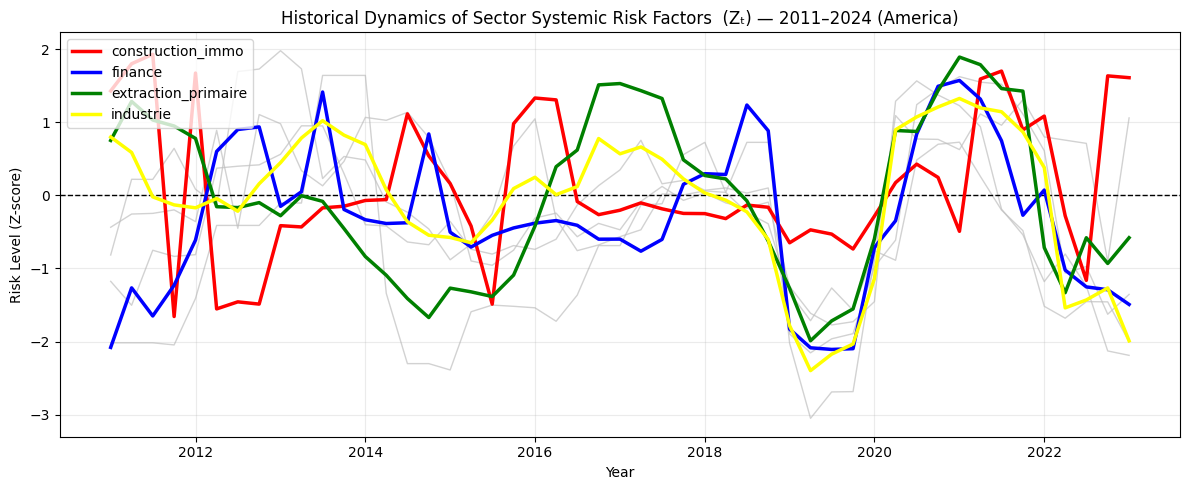

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_sector_systemic_risk_zt(
    df: pd.DataFrame,
    sector_col: str = "sector",
    date_col: str = "year_quarter",
    zt_col: str = "z_t",
    highlight: dict | None = None,
    start: str | None = "2011-01-01",
    end: str | None = "2024-12-31",
    title: str = "Historical Dynamics of Sector Systemic Risk Factors (Z\u209C) — 2011–2024",
):
    """
    df format (long):
        sector | year_quarter | z_t
    where year_quarter is a datetime-like (e.g., '2011-01-01') representing the quarter.

    highlight:
        dict mapping sector -> color, e.g.
        {"construction_immo": "red", "financials": "blue"}
        All non-highlighted sectors are plotted in light gray.

    start/end:
        optional date filters (inclusive).
    """
    d = df.copy()

    # Ensure datetime
    d[date_col] = pd.to_datetime(d[date_col])

    # Optional date filtering
    if start is not None:
        d = d[d[date_col] >= pd.to_datetime(start)]
    if end is not None:
        d = d[d[date_col] <= pd.to_datetime(end)]

    # Pivot to wide for plotting
    wide = (
        d.pivot(index=date_col, columns=sector_col, values=zt_col)
         .sort_index()
    )

    if highlight is None:
        highlight = {}

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot all "other" sectors in gray
    other_sectors = [c for c in wide.columns if c not in highlight]
    for sec in other_sectors:
        ax.plot(
            wide.index, wide[sec],
            color="0.75", linewidth=1.0, alpha=0.7, zorder=1
        )

    # Plot highlighted sectors
    for sec, color in highlight.items():
        if sec in wide.columns:
            ax.plot(
                wide.index, wide[sec],
                color=color, linewidth=2.5, label=sec, zorder=3
            )

    # Reference line at zero
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    # Formatting
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Risk Level (Z-score)")
    ax.grid(True, which="major", alpha=0.25)

    # X-axis ticks: every 2 years (adjust if you want)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Legend only for highlighted series
    if highlight:
        ax.legend(loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()


# ---------------- Example usage ----------------
# df columns: sector, year_quarter, z_t

highlight = {
    "construction_immo": "red",
    "finance": "blue",
    "extraction_primaire": "green",
    "industrie": "yellow",
}

plot_sector_systemic_risk_zt(
    Z_hat_gen,
    highlight=highlight,
    start="2011-01-01",
    end="2024-12-31",
    title="Historical Dynamics of Sector Systemic Risk Factors  (Z\u209C) — 2011–2024 (America)",
)

In [7]:
import pandas as pd

def get_zt_by_sector(df: pd.DataFrame, sector_name: str) -> pd.DataFrame:
    """
    Filtre un DataFrame contenant ['sector','year_quarter','z_t']
    et retourne les z_t pour le secteur demandé.

    Output:
        DataFrame avec colonnes:
        ['sector','year_quarter','z_t']
        trié par year_quarter
    """

    required_cols = {"sector", "year_quarter", "z_t"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Le DataFrame doit contenir {required_cols}")

    df_sector = (
        df[df["sector"] == sector_name]
        .copy()
    )

    if df_sector.empty:
        raise ValueError(f"Secteur '{sector_name}' non trouvé dans le DataFrame.")

    # Assure format datetime
    df_sector["year_quarter"] = pd.to_datetime(df_sector["year_quarter"])

    df_sector = df_sector.sort_values("year_quarter").reset_index(drop=True)

    return df_sector[["year_quarter", "z_t"]]

In [8]:
Z_hat= get_zt_by_sector(Z_hat_gen, "extraction_primaire")

In [9]:
Z_hat

,year_quarter,z_t
0,2010-07-01,2.534563
1,2010-10-01,0.635930
2,2011-01-01,0.751486
3,2011-04-01,1.284856
4,2011-07-01,1.030703
5,2011-10-01,0.949014
6,2012-01-01,0.778933
7,2012-04-01,-0.154775
8,2012-07-01,-0.166745
9,2012-10-01,-0.098714


In [10]:
Z_hat = Z_hat.rename(columns={"year_quarter": "date"})
Z_hat["date"] = pd.to_datetime(Z_hat["date"])
Z_hat = Z_hat.set_index("date")

In [11]:
# Charger le fichier Excel des macro données stationnaires
df_ts= pd.read_csv("data\macro_data\df_macro_stationary.csv")
df_ts["date"] = pd.to_datetime(df_ts["date"])
df_ts = df_ts.set_index("date")


In [12]:
len(df_ts.columns)

48

In [13]:
import pandas as pd

def split_japan_vs_rest(df: pd.DataFrame, jp_prefix: str = "JP_"):
    """
    Sépare un DataFrame en 2:
      - df_jp : colonnes qui commencent par JP_
      - df_rest : toutes les autres colonnes
    Conserve l'index tel quel.
    """
    jp_cols = [c for c in df.columns if c.startswith(jp_prefix)]
    rest_cols = [c for c in df.columns if not c.startswith(jp_prefix)]
    return df[jp_cols].copy(), df[rest_cols].copy()

In [14]:
df_jp, df_other = split_japan_vs_rest(df_ts)
df_am=df_other[[c for c in df_other.columns if c.startswith('US_')]]

print(df_jp.columns)     
print(df_other.columns)  
print(df_am.columns)

Index(['JP_GDP_Growth_Rate', 'JP_Inflation_rate', 'JP_Oil_price',
       'JP_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'JP_Effective_exchange_rate_hp_gap',
       'JP_Effective_exchange_rate_hp_gap_diff', 'JP_Equity_prices_log_hp_gap',
       'JP_GDP_log', 'JP_GDP_log_hp_gap', 'JP_GDP_log_hp_gap_diff',
       'JP_House_prices_residential_hp_gap',
       'JP_House_prices_residential_hp_gap_diff',
       'JP_Long_term_interest_rate_hp_gap',
       'JP_Long_term_interest_rate_hp_gap_diff', 'JP_Oil_price_log',
       'JP_Oil_price_log_hp_gap', 'JP_Unemployment_rate_hp_gap',
       'JP_Unemployment_rate_hp_gap_diff'],
      dtype='object')
Index(['EU_Central_bank_Intervention_rate_policy_interest_rate',
       'EU_GDP_Growth_Rate', 'US_GDP_Growth_Rate',
       'US_Long_term_interest_rate', 'US_Oil_price',
       'EU_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'EU_Effective_exchange_rate_hp_gap',
       'EU_Effective_exchange_rate_hp_gap_diff', '

In [15]:
len(df_jp.columns), len(df_other.columns), len(df_am.columns)

(18, 30, 18)

In [16]:
print(df_am.columns)

Index(['US_GDP_Growth_Rate', 'US_Long_term_interest_rate', 'US_Oil_price',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Effective_exchange_rate_hp_gap',
       'US_Effective_exchange_rate_hp_gap_diff', 'US_Equity_prices_log_hp_gap',
       'US_GDP_log', 'US_GDP_log_hp_gap', 'US_GDP_log_hp_gap_diff',
       'US_House_prices_residential_hp_gap',
       'US_House_prices_residential_hp_gap_diff',
       'US_Long_term_interest_rate_hp_gap',
       'US_Long_term_interest_rate_hp_gap_diff', 'US_Oil_price_log',
       'US_Oil_price_log_hp_gap', 'US_Unemployment_rate_hp_gap',
       'US_Unemployment_rate_hp_gap_diff'],
      dtype='object')


In [17]:
# Fusion avec Z_hat
df_macro_stationary = df_am.join(Z_hat, how="right")
df_macro_stationary

,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff,z_t
date,,,,,,,,,,,,,,,,,,,
2010-07-01,0.771085,2.786667,76.675000,0.000000,3.671997,-1.309716,-0.016660,-0.259957,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772,2.534563
2010-10-01,0.525110,2.863333,87.033160,0.000000,0.004494,-3.667503,0.050870,-0.644147,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033,0.635930
2011-01-01,-0.237205,3.460000,105.369424,0.000000,-1.191876,-1.196370,0.074041,NaN,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483,0.751486
2011-04-01,0.676582,3.210000,117.541905,0.000000,-2.781527,-1.589651,0.040477,-0.390701,0.153627,NaN,-2.560086,-1.732493,0.485613,-0.175677,4.766795,0.153057,0.163826,0.249117,1.284856
2011-07-01,-0.022313,2.426667,113.266948,0.000000,-2.484795,0.296731,-0.143873,NaN,NaN,NaN,-2.880002,-0.319915,-0.226518,-0.712131,4.729747,0.117724,0.313716,0.149890,1.030703
2011-10-01,1.123049,2.046667,109.978629,0.000000,-0.363614,2.121182,-0.067994,0.116047,0.674850,NaN,-3.224490,-0.344489,-0.539705,-0.313187,4.700286,0.092499,0.164448,-0.149268,0.949014
2012-01-01,0.838591,2.036667,118.427965,0.000000,-1.248360,-0.884746,0.015319,-0.176032,0.396404,-0.278446,-3.706151,-0.481661,-0.488408,0.051296,4.774305,0.173649,0.015895,-0.148553,0.778933
2012-04-01,0.446335,1.823333,109.060407,0.000000,0.174147,1.422507,-0.048181,-0.806686,-0.222201,-0.618605,-2.896281,0.809870,-0.646753,-0.158345,4.691902,0.101590,0.167829,0.151934,-0.154775
2012-07-01,0.144028,1.643333,110.133827,0.000000,-0.282129,-0.456277,-0.022249,-1.937748,-1.343793,-1.121592,-2.487834,0.408447,-0.778557,-0.131804,4.701696,0.125149,0.220008,0.052180,-0.166745


## MODELES SATELITES

In [18]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller

from scipy.stats import shapiro, jarque_bera
from itertools import combinations
from scipy.optimize import minimize


In [19]:
def make_lagged_features(df: pd.DataFrame, cols, lags=(0,1,2,3,4)):
    out = {}
    for c in cols:
        for L in lags:
            name = f"{c}_L{L}"
            out[name] = df[c] if L == 0 else df[c].shift(L)
    return pd.DataFrame(out, index=df.index)


In [20]:
def expand_expected_sign(expected_sign_base: dict, lags=(0,1,2,3,4)):
    exp = {}
    for var, sgn in expected_sign_base.items():
        for L in lags:
            exp[f"{var}_L{L}"] = sgn
    return exp

def sign_constraints_ok(params: pd.Series, expected_sign: dict, tol=1e-12):
    for var, sgn in expected_sign.items():
        if var in params.index:
            b = params[var]
            if abs(b) <= tol:
                continue
            if np.sign(b) != np.sign(sgn):
                return False
    return True


In [21]:
def fit_ols_hac(df, y_col, x_cols, hac_lags=4, add_const=True, min_obs=40):
    d = df[[y_col] + x_cols].dropna().copy()
    if d.shape[0] < min_obs:
        return None

    y = d[y_col].astype(float)
    X = d[x_cols].astype(float)
    if add_const:
        X = sm.add_constant(X, has_constant="add")

    try:
        ols = sm.OLS(y, X).fit()
        hac = ols.get_robustcov_results(cov_type="HAC", maxlags=hac_lags)
        return {"ols": ols, "hac": hac, "data": d, "X": X, "y": y}
    except Exception:
        return None


In [22]:
def build_admissible_model_space(
    df: pd.DataFrame,
    y_col: str,
    x_base_cols: list,
    expected_sign_base: dict,
    min_k=1,
    max_k=3,
    use_lags=True,
    lags=(0,1,2,3,4),
    verbose=True
):
    # features X (laggées ou non)
    if use_lags:
        Xfeat = make_lagged_features(df, x_base_cols, lags=lags)
        expected_sign = expand_expected_sign(expected_sign_base, lags=lags)
    else:
        Xfeat = df[x_base_cols].copy()
        expected_sign = expected_sign_base.copy()

    df_used = pd.concat([df[[y_col]], Xfeat], axis=1)

    all_models = []
    for k in range(min_k, max_k+1):
        for comb in combinations(Xfeat.columns.tolist(), k):
            all_models.append(list(comb))

    if verbose:
        print(f"Nb variables candidates: {Xfeat.shape[1]}")
        print(f"Nb modèles (combinaisons {min_k}..{max_k}): {len(all_models)}")

    rows = []
    admissible = []
    for i, x_cols in enumerate(all_models):
        fit = fit_ols_hac(df_used, y_col, x_cols, hac_lags=max(lags), min_obs=40)
        if fit is None:
            continue

        ok_sign = sign_constraints_ok(fit["ols"].params, expected_sign)
        rows.append({
            "model_id": i,
            "k": len(x_cols),
            "x_cols": x_cols,
            "ok_sign": ok_sign,
            "aic": fit["ols"].aic,
            "bic": fit["ols"].bic,
            "r2_adj": fit["ols"].rsquared_adj
        })
        if ok_sign:
            admissible.append({"name": f"m{i}", "x": x_cols})

    summary = pd.DataFrame(rows).sort_values(["ok_sign","bic"], ascending=[False, True])
    if verbose and not summary.empty:
        print("OK_sign:", int(summary["ok_sign"].sum()), "/", summary.shape[0])

    return summary, admissible, df_used


In [23]:
import numpy as np
import pandas as pd
from itertools import combinations

def build_admissible_model_space(
    df: pd.DataFrame,
    y_col: str,
    x_base_cols: list,
    min_k=1,
    max_k=3,
    use_lags=True,
    lags=(1,2,3,4),
    verbose=True
):
    # features X (laggées ou non)
    if use_lags:
        Xfeat = make_lagged_features(df, x_base_cols, lags=lags)
    else:
        Xfeat = df[x_base_cols].copy()

    df_used = pd.concat([df[[y_col]], Xfeat], axis=1)

    all_models = []
    for k in range(min_k, max_k + 1):
        for comb in combinations(Xfeat.columns.tolist(), k):
            all_models.append(list(comb))

    if verbose:
        print(f"Nb variables candidates: {Xfeat.shape[1]}")
        print(f"Nb modèles (combinaisons {min_k}..{max_k}): {len(all_models)}")

    rows = []
    admissible = []

    # Pour avoir des colonnes stables (même si une variable n'est pas dans le modèle)
    all_possible_terms = ["const"] + Xfeat.columns.tolist()

    for i, x_cols in enumerate(all_models):
        fit = fit_ols_hac(df_used, y_col, x_cols, hac_lags=max(lags), min_obs=40)
        if fit is None:
            continue

        ols = fit["ols"]

        # Coeffs du modèle (pandas Series indexée par nom de variable, ex: "const", "X1", ...)
        params = ols.params

        # On crée un dict de coeffs "complet" (NaN si la variable n'est pas dans le modèle)
        coef_dict = {f"coef_{term}": np.nan for term in all_possible_terms}
        for term, val in params.items():
            coef_dict[f"coef_{term}"] = float(val)

        rows.append({
            "model_id": i,
            "k": len(x_cols),
            "x_cols": x_cols,
            "aic": ols.aic,
            "bic": ols.bic,
            "r2_adj": ols.rsquared_adj,
            **coef_dict
        })

        admissible.append({"name": f"m{i}", "x": x_cols})

    summary = pd.DataFrame(rows).sort_values(["r2_adj"], ascending=[False])
    return summary, admissible, df_used

In [24]:
df_macro_stationary

# Train : strictement avant 2022
df_macro_stationary_train = df_macro_stationary.loc[df_macro_stationary.index < "2022-01-01"]

# Test : à partir de 2022
df_macro_stationary_test = df_macro_stationary.loc[df_macro_stationary.index >= "2022-01-01"]

In [25]:
len(df_macro_stationary_train), len(df_macro_stationary_test)

(46, 5)

In [26]:
x_base_cols=[c for c in df_macro_stationary.columns if c != "z_t"]
summary, admissible, df_used= build_admissible_model_space(df_macro_stationary,
    y_col='z_t',
    x_base_cols=x_base_cols,
    min_k=1,
    max_k=3,
    use_lags=True,
    lags=(1,2,3,4),
    verbose=True
)

Nb variables candidates: 72
Nb modèles (combinaisons 1..3): 62268


In [27]:
Xfeat_test = make_lagged_features(df_macro_stationary_test, x_base_cols, lags=(1,2,3,4))

df_used_test = pd.concat([df_macro_stationary_test[['z_t']], Xfeat_test], axis=1)

Xfeat_tot = make_lagged_features(df_macro_stationary, x_base_cols, lags=(1,2,3,4))

df_used_tot = pd.concat([df_macro_stationary[['z_t']], Xfeat_tot], axis=1)

In [28]:
def residual_diagnostics(fit_dict, lb_lags=12, alpha=0.05):
    ols = fit_dict["ols"]
    resid = ols.resid

    # ✅ exog réellement utilisé par le modèle (inclut la constante si elle est dans le modèle)
    X = ols.model.exog

    lb = acorr_ljungbox(resid, lags=[lb_lags], return_df=True)
    lb_p = float(lb["lb_pvalue"].iloc[0])

    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X)

    sh_p = shapiro(resid)[1] if len(resid) <= 5000 else np.nan
    jb_p = jarque_bera(resid)[1]

    adf_p = adfuller(resid.dropna(), autolag="AIC")[1] if resid.notna().sum() > 20 else np.nan
    dw = durbin_watson(resid)

    return {
        "n": int(len(resid)),
        "lb_pvalue": lb_p,
        "bp_pvalue": float(bp_p),
        "shapiro_pvalue": float(sh_p) if not np.isnan(sh_p) else np.nan,
        "jb_pvalue": float(jb_p),
        "adf_resid_pvalue": float(adf_p) if not np.isnan(adf_p) else np.nan,
        "dw": float(dw),
        "LB_ok_5pct": (lb_p > alpha),
        "BP_ok_5pct": (bp_p > alpha),
    }




In [29]:
import numpy as np

from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss


def normality_ok(resid, alpha=0.05, method="jb"):
    """
    Test de normalité des résidus.
    Retourne dict avec p-value + bool.
    method: "jb" (Jarque-Bera) par défaut.
    """
    resid = np.asarray(resid)
    resid = resid[~np.isnan(resid)]

    if resid.size < 8:  # JB pas super stable très petit n
        return {"norm_method": method, "norm_pvalue": np.nan, "norm_ok": False}

    if method.lower() == "jb":
        jb_stat, jb_pvalue, skew, kurt = jarque_bera(resid)
        return {
            "norm_method": "JB",
            "norm_stat": float(jb_stat),
            "norm_pvalue": float(jb_pvalue),
            "norm_ok": bool(jb_pvalue > alpha),
            "skew": float(skew),
            "kurtosis": float(kurt),
        }

    raise ValueError("method must be 'jb'")


def stationarity_ok(resid, alpha=0.05, method="adf", kpss_regression="c"):
    """
    Test de stationnarité des résidus.
    method:
      - "adf": H0 = racine unitaire (non-stationnaire) => ok si pvalue < alpha
      - "kpss": H0 = stationnaire => ok si pvalue > alpha
      - "both": exige ADF ok ET KPSS ok (plus strict)
    """
    resid = np.asarray(resid)
    resid = resid[~np.isnan(resid)]

    if resid.size < 12:
        return {
            "stat_method": method.upper(),
            "stat_ok": False,
            "adf_pvalue": np.nan,
            "kpss_pvalue": np.nan,
        }

    out = {"stat_method": method.upper()}

    if method.lower() in ("adf", "both"):
        # autolag='AIC' est un bon défaut
        adf = adfuller(resid, autolag="AIC")
        adf_stat, adf_pvalue = adf[0], adf[1]
        out.update({"adf_stat": float(adf_stat), "adf_pvalue": float(adf_pvalue)})
        adf_ok = (adf_pvalue < alpha)
    else:
        adf_ok = True

    if method.lower() in ("kpss", "both"):
        # Attention: KPSS peut warning si série très stationnaire; on attrape et garde pvalue
        try:
            kpss_res = kpss(resid, regression=kpss_regression, nlags="auto")
            kpss_stat, kpss_pvalue = kpss_res[0], kpss_res[1]
        except Exception:
            kpss_stat, kpss_pvalue = np.nan, np.nan
        out.update({"kpss_stat": float(kpss_stat) if np.isfinite(kpss_stat) else np.nan,
                    "kpss_pvalue": float(kpss_pvalue) if np.isfinite(kpss_pvalue) else np.nan})
        kpss_ok = (np.isnan(kpss_pvalue) == False) and (kpss_pvalue > alpha)
    else:
        kpss_ok = True

    if method.lower() == "adf":
        out["stat_ok"] = bool(adf_ok)
    elif method.lower() == "kpss":
        out["stat_ok"] = bool(kpss_ok)
    elif method.lower() == "both":
        out["stat_ok"] = bool(adf_ok and kpss_ok)
    else:
        raise ValueError("method must be 'adf', 'kpss', or 'both'")

    return out


def hac_significance_ok(hac_result, x_cols, alpha=0.05, min_sig=1, exclude_const=True):
    """
    Vérifie la significativité individuelle des coefficients (p-values HAC).
    - hac_result: typiquement fit["hac"] (statsmodels RegressionResults robustes)
    - x_cols: liste des variables explicatives (sans y)
    - exclude_const: ignore 'const' si présent
    - min_sig: nombre minimum de coefficients significatifs requis
    """
    # pvalues est une Series indexée par noms de params
    pvals = hac_result.pvalues

    params = list(pvals.index)

    if exclude_const and "const" in params:
        params = [p for p in params if p != "const"]

    # Si tes x_cols sont les vrais noms dans la régression, on restreint à ceux-là
    # (sinon on prend tout sauf const)
    if x_cols is not None and len(x_cols) > 0:
        # garde seulement ceux présents (robuste aux noms)
        params = [p for p in params if p in set(x_cols)]

    sig_count = int(np.sum(pvals.loc[params] < alpha)) if len(params) else 0

    return (sig_count >= min_sig)

In [30]:
def residual_diagnostics_full(
    fit,
    lb_lags=12,
    alpha=0.05,
    normality=True,
    norm_alpha=0.05,
    norm_method="jb",
    stationarity=True,
    stat_alpha=0.05,
    stat_method="adf",   # "adf" / "kpss" / "both"
):
    """
    Combine tes diagnostics existants + normalité + stationnarité.
    """
    diag = residual_diagnostics(fit, lb_lags=lb_lags, alpha=alpha)

    resid = fit["ols"].resid

    if normality:
        diag.update(normality_ok(resid, alpha=norm_alpha, method=norm_method))
    else:
        diag.update({"norm_ok": True, "norm_pvalue": np.nan, "norm_method": None})

    if stationarity:
        diag.update(stationarity_ok(resid, alpha=stat_alpha, method=stat_method))
    else:
        diag.update({"stat_ok": True, "adf_pvalue": np.nan, "kpss_pvalue": np.nan, "stat_method": None})

    return diag, resid

In [31]:
def hac_significance_ok(hac_res, x_cols, alpha=0.05, min_sig=1):
    pvals = pd.Series(hac_res.pvalues, index=hac_res.model.exog_names)
    vars_in = [v for v in x_cols if v in pvals.index]
    if not vars_in:
        return False
    return int((pvals[vars_in] < alpha).sum()) >= min_sig

def build_candidate_pool_and_filter(
    df, y_col, candidate_models,
    hac_lags=4, lb_lags=12, alpha=0.05,
    require_sig=False, sig_alpha=0.05, min_sig=1,
    enforce_bp=False, enforce_lb=True,
    enforce_norm=False, norm_alpha=0.05, norm_method="jb",
    enforce_stat=False, stat_alpha=0.05, stat_method="adf",
):
    summary_rows = []

    for m in candidate_models:
        x_cols = m["x"]
        fit = fit_ols_hac(df, y_col, x_cols, hac_lags=hac_lags)
        if fit is None:
            continue

        diag, resid = residual_diagnostics_full(
            fit,
            lb_lags=lb_lags,
            alpha=alpha,
            normality=enforce_norm,
            norm_alpha=norm_alpha,
            norm_method=norm_method,
            stationarity=enforce_stat,
            stat_alpha=stat_alpha,
            stat_method=stat_method,
        )
        

        ok_sig = True
        if require_sig:
            ok_sig = hac_significance_ok(
                fit["hac"], x_cols, alpha=sig_alpha, min_sig=len(x_cols) if min_sig == "all" else min_sig
            )

        ok_lb = diag.get("LB_ok_5pct", True) if enforce_lb else True
        ok_bp = diag.get("BP_ok_5pct", True) if enforce_bp else True
        ok_norm = diag.get("norm_ok", True) if enforce_norm else True
        ok_stat = diag.get("stat_ok", True) if enforce_stat else True

        ok = ok_sig and ok_lb and ok_bp and ok_norm and ok_stat

        summary_rows.append({
            "model": m.get("name", str(tuple(x_cols))),
            "x_cols": tuple(x_cols),
            "ok": ok,
            "k": len(x_cols),
            "aic": fit["ols"].aic,
            "bic": fit["ols"].bic,
            "r2_adj": fit["ols"].rsquared_adj,
            "ok_lb": ok_lb,
            "ok_bp": ok_bp,
            "ok_sig": ok_sig,
            "ok_norm": ok_norm,
            "ok_stat": ok_stat,
            "resid": resid,
            **diag
        })

    summary = pd.DataFrame(summary_rows)

    if summary.empty:
        return [], summary

    summary_ok = summary[summary["ok"]].copy()
    summary_top = summary_ok.sort_values("aic")

    kept = [
        m for m in candidate_models
        if tuple(m["x"]) in set(summary_top["x_cols"])
    ]

    summary = summary.sort_values(["ok", "aic"], ascending=[False, True])

    return kept, summary

In [32]:
y_col='z_t'
x_cols = [c for c in df_used.columns if c != "z_t"]

kept, summary1= build_candidate_pool_and_filter(
    df_used, y_col, admissible,
    hac_lags=4, lb_lags=12, alpha=0.05,
    require_sig=True, sig_alpha=0.05, min_sig="all",
    enforce_bp=True, enforce_lb=True,
    enforce_norm=True, norm_alpha=0.05, norm_method="jb",
    enforce_stat=True, stat_alpha=0.05, stat_method="adf",
)
len(kept)

175

In [33]:
def solve_simplex_weights_slsqp(Y, y):
    """
    Min ||y - Yw||^2 s.c w>=0, sum w = 1
    """
    T, M = Y.shape
    w0 = np.ones(M) / M

    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
    )
    bounds = [(0.0, 1.0)] * M

    def obj(w):
        r = y - Y @ w
        return float(r.T @ r)

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        return None
    return res.x


In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ---------------------------
# ETAPE 1 : prédictions LOO
# ---------------------------

def loo_pred_one_model(df, y_col, x_cols, hac_lags=4, add_const=True, min_obs=40):
    """
    Pour UN modèle : calcule f_k^{(-t)}(x_t) pour chaque t (LOO).
    Retour: Series indexée comme df.index (NaN si non calculable)
    """
    d = df[[y_col] + x_cols].copy()
    d = d.dropna(subset=[y_col] + x_cols)  # LOO défini seulement si y et X existent

    yhat_loo = pd.Series(index=df.index, dtype=float)

    for t in d.index:
        d_minus = d.drop(index=t)
        if len(d_minus) < min_obs:
            continue

        fit = fit_ols_hac(d_minus, y_col, x_cols, hac_lags=hac_lags, min_obs=min_obs)
        if fit is None:
            continue

        ols = fit["ols"]
        x_t = d.loc[t, x_cols].astype(float)

        X_t = pd.DataFrame([x_t.values], columns=x_cols)
        if add_const:
            X_t = sm.add_constant(X_t, has_constant="add")

        yhat_loo.loc[t] = float(ols.predict(X_t).iloc[0])

    return yhat_loo


def build_P_loo(df, y_col, kept_models, hac_lags=4, add_const=True, min_obs=40):
    """
    Construit la matrice P_loo : colonnes = modèles, lignes = dates, valeurs = prédictions LOO.
    """
    preds = {}
    for i, m in enumerate(kept_models):
        name = m.get("name", f"m{i}")
        preds[name] = loo_pred_one_model(
            df=df, y_col=y_col, x_cols=m["x"],
            hac_lags=hac_lags, add_const=add_const, min_obs=min_obs
        )
    return pd.DataFrame(preds)


# ---------------------------
# ETAPE 2 : apprendre les poids (simplex)
# ---------------------------

def learn_simplex_weights_from_loo(df, y_col, P_loo):
    """
    Apprend w = argmin sum_t (y_t - sum_k w_k P_loo[t,k])^2
    s.c. sum w_k = 1 et w_k >= 0
    """
    d_w = pd.concat([df[[y_col]], P_loo], axis=1).dropna()  # intersection où tout existe

    y = d_w[y_col].values
    Y = d_w[P_loo.columns].values

    w = solve_simplex_weights_slsqp(Y, y)
    if w is None:
        raise RuntimeError("Le solveur des poids a échoué.")

    weights = pd.Series(w, index=P_loo.columns, name="w_opt")
    return weights, d_w


# ---------------------------
# ETAPE 3 : refit full sample + prédictions finales + JMA
# ---------------------------

def full_fit_predict_one_model(df, y_col, x_cols, hac_lags=4, add_const=True, min_obs=40):
    """
    Refit le modèle sur tout l'échantillon (dropna sur y et X), puis prédit partout où X existe.
    """
    d_fit = df[[y_col] + x_cols].copy().dropna(subset=[y_col] + x_cols)

    fit = fit_ols_hac(d_fit, y_col, x_cols, hac_lags=hac_lags, min_obs=min_obs)
    if fit is None:
        return pd.Series(index=df.index, dtype=float)

    ols = fit["ols"]

    d_pred = df[x_cols].copy().dropna(subset=x_cols)
    X_pred = d_pred.astype(float)
    if add_const:
        X_pred = sm.add_constant(X_pred, has_constant="add")

    yhat = pd.Series(index=df.index, dtype=float)
    yhat.loc[d_pred.index] = ols.predict(X_pred).values
    return yhat



def jma_step_by_step(df, y_col, kept_models, hac_lags=4, add_const=True, min_obs=40):
    """
    Pipeline complet en 3 étapes avec contrainte K* = floor(3*T^(1/3)),
    en sélectionnant les K* modèles avec plus faible perte LOO.
    """
    # ----- CONTRAINTE SUR LE NB DE MODÈLES -----
    T = int(df[y_col].notna().sum())
    K_star = int(np.floor(3 * (T ** (1/3))))
    K_star = max(1, K_star)

    if len(kept_models) > K_star:
        # 1) LOO sur tous les candidats (pour scorer)
        P_loo_all = build_P_loo(df, y_col, kept_models, hac_lags=hac_lags, add_const=add_const, min_obs=min_obs)

        # 2) Score par modèle: MSE sur les lignes où on a prédiction + y
        y = df[y_col]
        scores = {}
        for col in P_loo_all.columns:
            mask = P_loo_all[col].notna() & y.notna()
            if mask.sum() == 0:
                scores[col] = np.inf
            else:
                err = (y[mask] - P_loo_all.loc[mask, col])
                scores[col] = float((err**2).mean())

        # 3) Prendre les K* meilleurs
        best_names = [k for k, _ in sorted(scores.items(), key=lambda kv: kv[1])[:K_star]]

        # 4) Filtrer kept_models en gardant l'ordre des meilleurs
        name_to_model = {m.get("name", f"m{i}"): m for i, m in enumerate(kept_models)}
        # Si certains modèles n'ont pas de "name", assure-toi qu'ils en ont une en amont.
        kept_models = [name_to_model[n] for n in best_names if n in name_to_model]

    # ----- PIPELINE NORMAL -----
    P_loo = build_P_loo(df, y_col, kept_models, hac_lags=hac_lags, add_const=add_const, min_obs=min_obs)
    weights, oos_frame = learn_simplex_weights_from_loo(df, y_col, P_loo)

    preds_full = {}
    for i, m in enumerate(kept_models):
        name = m.get("name", f"m{i}")
        preds_full[name] = full_fit_predict_one_model(
            df=df, y_col=y_col, x_cols=m["x"],
            hac_lags=hac_lags, add_const=add_const, min_obs=min_obs
        )
    P_full = pd.DataFrame(preds_full)
    d_pred = P_full.dropna()
    yhat_jma = pd.Series(d_pred.values @ weights.values, index=d_pred.index, name="yhat_jma")
    return yhat_jma, weights, oos_frame, P_loo, P_full, K_star



In [34]:
res=jma_step_by_step(df_used, y_col='z_t', kept_models=kept, hac_lags=4, add_const=True, min_obs=40)

In [36]:

#y_meta_col=res[0]
best_row = (
    summary1
    .query("ok == True")
    .sort_values("aic", ascending=True)
    .iloc[0]
)

best_model_name = best_row["model"]
best_model_name
best_model = next(
    m for m in admissible if m["name"] == best_model_name
)

x_best = best_model["x"]

df2 = df_used[[y_col] + x_best].dropna()

fit = fit_ols_hac(df2, y_col, x_best, hac_lags=4)
ols = fit["ols"]

X = df2[x_best].astype(float)
X = sm.add_constant(X, has_constant="add")
yhat_best = pd.Series(ols.predict(X), index=df2.index, name="yhat_best")

y_indiv_col=yhat_best

x_best


['US_House_prices_residential_hp_gap_L1',
 'US_Long_term_interest_rate_hp_gap_L3',
 'US_Oil_price_log_hp_gap_L4']

In [41]:
best_row

model                                                          m57554
x_cols              (US_House_prices_residential_hp_gap_L1, US_Lon...
ok                                                               True
k                                                                   3
aic                                                         75.662328
bic                                                         83.062919
r2_adj                                                       0.775637
ok_lb                                                            True
ok_bp                                                            True
ok_sig                                                           True
ok_norm                                                          True
ok_stat                                                          True
resid               date
2011-07-01   -0.226968
2011-10-01    0.53...
n                                                                  47
lb_pvalue           

In [39]:
summary1

,model,x_cols,ok,k,aic,bic,r2_adj,ok_lb,ok_bp,ok_sig,...,norm_method,norm_stat,norm_pvalue,norm_ok,skew,kurtosis,stat_method,adf_stat,adf_pvalue,stat_ok
46228,m57554,"(US_House_prices_residential_hp_gap_L1, US_Lon...",True,3,75.662328,83.062919,0.775637,True,True,True,...,JB,0.772552,0.679583,True,-0.069252,2.387373,ADF,-5.222397,0.000008,True
46683,m58009,"(US_House_prices_residential_hp_gap_L2, US_Lon...",True,3,76.163698,83.564288,0.773231,True,True,True,...,JB,0.320635,0.851873,True,0.044596,2.605318,ADF,-4.559893,0.000153,True
15971,m18279,"(US_Long_term_interest_rate_L3, US_House_price...",True,3,76.721151,84.121741,0.770525,True,True,True,...,JB,0.251522,0.881826,True,-0.006786,2.641877,ADF,-3.249754,0.017279,True
46207,m57533,"(US_House_prices_residential_hp_gap_L1, US_Lon...",True,3,77.120445,84.521035,0.768567,True,True,True,...,JB,1.132194,0.567737,True,-0.244841,2.418318,ADF,-5.194769,0.000009,True
43083,m51221,"(US_GDP_log_L3, US_House_prices_residential_hp...",True,3,77.305284,84.159572,0.685924,True,True,True,...,JB,0.490333,0.782574,True,0.266929,3.044954,ADF,-4.394897,0.000303,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3226,m3596,"(US_GDP_Growth_Rate_L1, US_Effective_exchange_...",False,3,157.441126,165.089218,-0.064058,False,True,False,...,JB,2.952993,0.228437,True,0.027813,1.810739,ADF,-3.662737,0.004669,True
3254,m3624,"(US_GDP_Growth_Rate_L1, US_Effective_exchange_...",False,3,157.443487,165.091579,-0.064108,False,True,False,...,JB,2.972456,0.226224,True,0.028904,1.806921,ADF,-3.675580,0.004470,True
4040,m4644,"(US_GDP_Growth_Rate_L1, US_House_prices_reside...",False,3,157.448057,165.096149,-0.064205,False,True,False,...,JB,2.955947,0.228099,True,0.025507,1.809936,ADF,-3.665002,0.004633,True
30736,m35564,"(US_Effective_exchange_rate_hp_gap_L1, US_Hous...",False,3,157.453301,165.101393,-0.064317,False,True,False,...,JB,2.987989,0.224474,True,0.027816,1.803697,ADF,-3.609839,0.005576,True


In [37]:
print(ols.params, ols.pvalues)

const                                   -0.160189
US_House_prices_residential_hp_gap_L1   -0.168990
US_Long_term_interest_rate_hp_gap_L3    -0.661791
US_Oil_price_log_hp_gap_L4              -3.632411
dtype: float64 const                                    4.543618e-02
US_House_prices_residential_hp_gap_L1    3.448532e-06
US_Long_term_interest_rate_hp_gap_L3     9.854142e-05
US_Oil_price_log_hp_gap_L4               2.447850e-12
dtype: float64


In [51]:
res[1]

m57554    0.000000e+00
m58009    1.323969e-02
m57574    2.178572e-01
m57533    0.000000e+00
m57989    0.000000e+00
m18279    2.133332e-01
m53097    1.466562e-01
m52889    0.000000e+00
m47816    9.368740e-03
m32009    3.336090e-16
m39017    3.995449e-01
Name: w_opt, dtype: float64

In [50]:
for mod in res[1].index:
    model = next(m for m in admissible if m["name"] == mod)
    x= model["x"]
    print(mod, x)
    

m57554 ['US_House_prices_residential_hp_gap_L1', 'US_Long_term_interest_rate_hp_gap_L3', 'US_Oil_price_log_hp_gap_L4']
m58009 ['US_House_prices_residential_hp_gap_L2', 'US_Long_term_interest_rate_hp_gap_L4', 'US_Oil_price_log_hp_gap_L4']
m57574 ['US_House_prices_residential_hp_gap_L1', 'US_Long_term_interest_rate_hp_gap_L4', 'US_Oil_price_log_hp_gap_L4']
m57533 ['US_House_prices_residential_hp_gap_L1', 'US_Long_term_interest_rate_hp_gap_L2', 'US_Oil_price_log_hp_gap_L4']
m57989 ['US_House_prices_residential_hp_gap_L2', 'US_Long_term_interest_rate_hp_gap_L3', 'US_Oil_price_log_hp_gap_L4']
m18279 ['US_Long_term_interest_rate_L3', 'US_House_prices_residential_hp_gap_diff_L3', 'US_Oil_price_log_hp_gap_L4']
m53097 ['US_GDP_log_hp_gap_L1', 'US_Oil_price_log_hp_gap_L4', 'US_Unemployment_rate_hp_gap_diff_L1']
m52889 ['US_GDP_log_hp_gap_L1', 'US_Long_term_interest_rate_hp_gap_L2', 'US_Oil_price_log_hp_gap_L4']
m47816 ['US_Equity_prices_log_hp_gap_L3', 'US_Long_term_interest_rate_hp_gap_L1', 'US

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_predictions_like_example(
    df,
    date_col="date",          # colonne date (datetime ou convertible)
    y_true_col="y_true",      # facteur systémique "véritable"
    y_indiv_col="y_indiv",    # prédiction d'un modèle individuel
    y_meta_col="y_meta",      # prédiction du méta-modèle (stacking/JMA)
    sector_name="Extractions_primaires",
    r2_indiv=None,            # si None -> calculé
    r2_meta=None,             # si None -> calculé
    title_prefix="In sample forcast for sector : ",
    figsize=(12, 5),
    savepath=None
):
    """
    Reproduit un graphe proche de ton exemple:
    - noir: y_true
    - bleu: y_indiv
    - rouge pointillé: y_meta
    - ligne horizontale y=0 en gris pointillé
    - légende avec R² adj (ici on met R² simple; si tu veux l'ajusté, passe-le via r2_*)

    df doit contenir au minimum: date_col, y_true_col, y_indiv_col, y_meta_col.
    """
    d = df[[date_col, y_true_col, y_indiv_col, y_meta_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna().sort_values(date_col)

    y_true = d[y_true_col].astype(float).values
    y_ind  = d[y_indiv_col].astype(float).values
    y_meta = d[y_meta_col].astype(float).values

    def r2(y, yhat):
        if len(y) < 2:
            return np.nan
        sse = np.sum((y - yhat) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return np.nan if sst == 0 else 1 - sse / sst

    if r2_indiv is None:
        r2_indiv = r2(y_true, y_ind)
    if r2_meta is None:
        r2_meta = r2(y_true, y_meta)

    plt.figure(figsize=figsize)
    plt.plot(d[date_col], y_true, linewidth=2.5, label="True Systemic Risk Factor", color="black")
    plt.plot(d[date_col], y_ind,  linewidth=2.0, label=f"Individual Model (R² adj. = {r2_indiv:.2f})")
    plt.plot(d[date_col], y_meta, linewidth=2.0, linestyle="--",
             label=f"Meta-model (R² adj. = {r2_meta:.2f})")

    plt.axhline(0, linestyle="--", linewidth=1.0, alpha=0.7)
    plt.grid(True, alpha=0.35)

    plt.title(f"{title_prefix}{sector_name}", fontsize=14)
    plt.ylabel("Systemic Risk Factor", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(loc="upper left", frameon=True)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()


# ==========================
# EXEMPLE D’UTILISATION
# ==========================
# Tu peux construire df_plot à partir de tes objets:
# - Z observé : df_macro_stationary["Z_..."]
# - prédiction modèle individuel : yhat_best (Series)
# - prédiction méta-modèle : yhat_stacked (Series)

# Exemple type (adapte les noms):
y_col = y_col  # ou "Z_EXTRACTIONS_PRIMAIRES"
y_true = df_macro_stationary[y_col]
yhat_indiv =yhat_best           # Series indexée par date
yhat_meta = y_meta_col   # Series indexée par date
#
df_plot = pd.concat(
    [y_true.rename("y_true"),
     yhat_indiv.rename("y_indiv"),
     yhat_meta.rename("y_meta")],
    axis=1
).reset_index().rename(columns={"index": "date"})
#
plot_predictions_like_example(
    df_plot,
    date_col="date",
    y_true_col="y_true",
    y_indiv_col="y_indiv",
    y_meta_col="y_meta",
    sector_name="Primary Extractions",
 )


NameError: name 'y_meta_col' is not defined

In [37]:
resid_finance=best_row["resid"]


In [38]:
resid_finance.to_csv("data/facteurs_systemiq/resid_services_pro.csv", index=True)

In [39]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2

def fit_ols_residuals(df, y_col, x_cols, add_const=True, min_obs=40):
    """
    Estime OLS (sous H0 d'indépendance des équations) et renvoie une Series de résidus alignée sur l'index.
    """
    d = df[[y_col] + list(x_cols)].dropna()
    if len(d) < min_obs:
        # pas assez d'obs -> renvoyer série vide (ou lever une erreur selon ton choix)
        return pd.Series(dtype=float, name=y_col)

    y = d[y_col].astype(float)
    X = d[list(x_cols)].astype(float)
    if add_const:
        X = sm.add_constant(X, has_constant="add")

    res = sm.OLS(y, X).fit()
    eps = res.resid
    eps.name = y_col
    return eps

def breusch_pagan_contemp_test(resid_df):
    """
    resid_df: DataFrame T x m de résidus (alignés), colonnes=secteurs.
    Retourne BP, df, pvalue, R (corr matrix).
    """
    # Assure un échantillon complet
    E = resid_df.dropna(axis=0, how="any")
    T = E.shape[0]
    m = E.shape[1]
    if m < 2:
        raise ValueError("Il faut au moins 2 équations (m>=2) pour le test.")
    if T <= 1:
        raise ValueError("Pas assez d'observations alignées pour calculer une corrélation.")

    R = E.corr()

    # Somme des carrés hors-diagonale (i<j)
    r2_sum = 0.0
    cols = R.columns
    for i in range(m):
        for j in range(i+1, m):
            rij = R.loc[cols[i], cols[j]]
            if pd.notna(rij):
                r2_sum += float(rij**2)

    BP = T * r2_sum
    df_chi = m * (m - 1) / 2
    pval = 1 - chi2.cdf(BP, df_chi)

    return {
        "T": T,
        "m": m,
        "BP": BP,
        "df": df_chi,
        "pvalue": pval,
        "R": R
    }

def run_bp_pipeline(df, eq_specs, add_const=True, min_obs=40):
    """
    eq_specs = {
      "sector1": {"y": "y_col1", "x": ["x1","x2"]},
      "sector2": {"y": "y_col2", "x": ["x1","x3"]},
      ...
    }
    """
    resid_map = {}
    for sector, spec in eq_specs.items():
        eps = fit_ols_residuals(
            df=df,
            y_col=spec["y"],
            x_cols=spec["x"],
            add_const=add_const,
            min_obs=min_obs
        )
        resid_map[sector] = eps

    resid_df = pd.concat(resid_map, axis=1)  # colonnes = secteurs
    out = breusch_pagan_contemp_test(resid_df)

    # Bonus: top corrélations absolues
    R = out["R"].copy()
    np.fill_diagonal(R.values, np.nan)
    top_pairs = (
        R.abs()
        .stack()
        .sort_values(ascending=False)
    )
    out["top_abs_corr_pairs"] = top_pairs.head(15)

    return out, resid_df

In [40]:
var_finance=['US_GDP_log_hp_gap_L2',
 'US_House_prices_residential_hp_gap_L3',
 'US_Long_term_interest_rate_hp_gap_L4']
var_extraction= ['US_GDP_log_hp_gap_L1',
 'US_Long_term_interest_rate_hp_gap_L2',
 'US_Oil_price_log_hp_gap_L4']
var_construction= ['US_Long_term_interest_rate_L4',
 'US_Equity_prices_log_hp_gap_L4',
 'US_GDP_log_hp_gap_L2']
var_industrie=['US_GDP_log_L1',
 'US_GDP_log_hp_gap_L1',
 'US_Long_term_interest_rate_hp_gap_L3']
var_info_com=['US_Effective_exchange_rate_hp_gap_diff_L3',
 'US_GDP_log_L1',
 'US_Unemployment_rate_hp_gap_L1']
var_public=['US_GDP_log_L4',
 'US_GDP_log_hp_gap_L4',
 'US_House_prices_residential_hp_gap_L4']
var_services=['US_GDP_log_hp_gap_L3',
 'US_House_prices_residential_hp_gap_L3',
 'US_Long_term_interest_rate_hp_gap_L4']

In [41]:
"""import pandas as pd

# 1) récupérer (model_id, weight) depuis res["selected_models"]
sel = pd.DataFrame(res["selected_models"])
sel["model_id"] = sel["name"].str.replace("m", "", regex=False).astype(int)
sel["weight"] = sel["weight"].astype(float)

# 2) joindre avec summary
df_sel = summary.merge(sel[["model_id", "weight"]], on="model_id", how="inner")

df_sel.drop(columns=["bic"], inplace=True)
df_sel = df_sel[df_sel["weight"].abs() > 1e-10]
df_sel = df_sel.fillna(0)
df_sel
"""

'import pandas as pd\n\n# 1) récupérer (model_id, weight) depuis res["selected_models"]\nsel = pd.DataFrame(res["selected_models"])\nsel["model_id"] = sel["name"].str.replace("m", "", regex=False).astype(int)\nsel["weight"] = sel["weight"].astype(float)\n\n# 2) joindre avec summary\ndf_sel = summary.merge(sel[["model_id", "weight"]], on="model_id", how="inner")\n\ndf_sel.drop(columns=["bic"], inplace=True)\ndf_sel = df_sel[df_sel["weight"].abs() > 1e-10]\ndf_sel = df_sel.fillna(0)\ndf_sel\n'

In [42]:
#df_sel.to_csv("averaging_model_finance.csv", index=False)